In [65]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
os.environ["KERAS_BACKEND"] = "torch"
import keras
print(keras.backend.backend())
from keras.models import Sequential
from keras.optimizers import Adam
from keras.layers import Convolution2D, Flatten, Dense
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split
import albumentations as A
import cv2
import pandas as pd
import random
import ntpath

torch


In [2]:
data_dir = 'sim_data'
columns = ['left', 'center', 'right', 'mask', 'steering']
data = pd.read_csv(os.path.join(data_dir, 'driving_log.csv'), names=columns)
pd.set_option('display.max_colwidth', None)
data.head()

,left,center,right,mask,steering
0,left,center,right,mask,steering
1,driving_model/sim_data/RGB\left_00000.png,driving_model/sim_data/RGB\center_00000.png,driving_model/sim_data/RGB\right_00000.png,driving_model/sim_data/masks\00000.png,-0.007275240961462259
2,driving_model/sim_data/RGB\left_00001.png,driving_model/sim_data/RGB\center_00001.png,driving_model/sim_data/RGB\right_00001.png,driving_model/sim_data/masks\00001.png,-0.00592057267203927
3,driving_model/sim_data/RGB\left_00002.png,driving_model/sim_data/RGB\center_00002.png,driving_model/sim_data/RGB\right_00002.png,driving_model/sim_data/masks\00002.png,-0.004843179602175951
4,driving_model/sim_data/RGB\left_00003.png,driving_model/sim_data/RGB\center_00003.png,driving_model/sim_data/RGB\right_00003.png,driving_model/sim_data/masks\00003.png,-0.003970347810536623


In [3]:
def path_leaf(path):
    head, tail = ntpath.split(path)
    return tail
data['center'] = data['center'].apply(path_leaf)
data['left'] = data['left'].apply(path_leaf)
data['right'] = data['right'].apply(path_leaf)

data.head()

,left,center,right,mask,steering
0,left,center,right,mask,steering
1,left_00000.png,center_00000.png,right_00000.png,driving_model/sim_data/masks\00000.png,-0.007275240961462259
2,left_00001.png,center_00001.png,right_00001.png,driving_model/sim_data/masks\00001.png,-0.00592057267203927
3,left_00002.png,center_00002.png,right_00002.png,driving_model/sim_data/masks\00002.png,-0.004843179602175951
4,left_00003.png,center_00003.png,right_00003.png,driving_model/sim_data/masks\00003.png,-0.003970347810536623


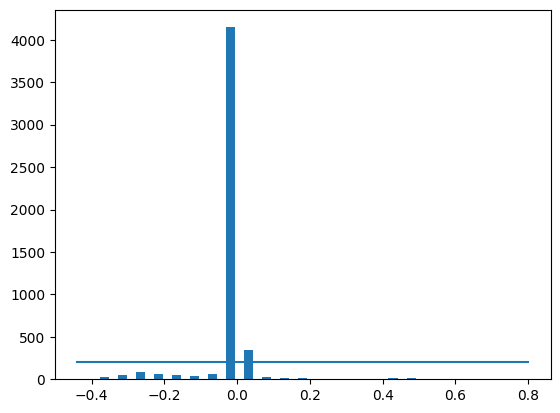

In [4]:
data['steering'] = pd.to_numeric(data['steering'], errors='coerce')
data = data.dropna(subset=['steering'])
num_bins = 25
samples_per_bin = 200
hist, bins = np.histogram(data['steering'], num_bins)
center = (bins[:-1] + bins[1:]) * 0.5
plt.bar(center, hist, width=0.025)
plt.plot((np.min(data['steering']), np.max(data['steering'])), (samples_per_bin, samples_per_bin))

length of data 5000
removed 4091
remaining data 909


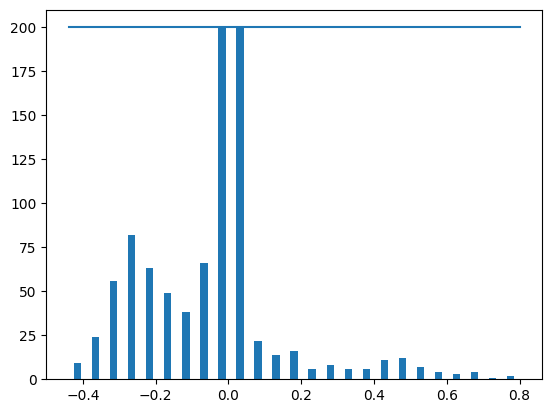

In [5]:
print(f"length of data {len(data)}")
remove_list = []

for j in range(num_bins):
    list_ = []
    for i in range(len(data['steering'])):
        if data['steering'].iloc[i] >= bins[j] and data['steering'].iloc[i] <= bins[j+1]:
            list_.append(i)
    list_ = shuffle(list_)
    list_ = list_[samples_per_bin:]
    remove_list.extend(list_)

print(f'removed {len(remove_list)}')
data.drop(data.index[remove_list], inplace=True)
print(f'remaining data {len(data)}')

hist, _ = np.histogram(data['steering'], (num_bins))
plt.bar(center, hist, width=0.02)
plt.plot((np.min(data['steering']), np.max(data['steering'])), (samples_per_bin, samples_per_bin))

In [6]:
print(data.iloc[1])
def load_img_steering(rgb_dir, df):
    rgb_path = []
    steering = []
    for i in range(len(data)):
        indexed_data = data.iloc[i]
        center, left, right = indexed_data[0], indexed_data[1], indexed_data[2]
        rgb_path.append(os.path.join(rgb_dir, center.strip()))
        steering.append(float(indexed_data[4]))
        rgb_path.append(os.path.join(rgb_dir, left.strip()))
        steering.append(float(indexed_data[4]) + 0.15)
        rgb_path.append(os.path.join(rgb_dir, right.strip()))
        steering.append(float(indexed_data[4]) - 0.15)
    rgb_paths = np.asarray(rgb_path)
    steerings = np.asarray(steering)

    return rgb_paths, steerings

rgb_paths, steerings = load_img_steering(data_dir + '/RGB', data)

left                                left_00025.png
center                            center_00025.png
right                              right_00025.png
mask        driving_model/sim_data/masks\00025.png
steering                                 -0.014022
Name: 26, dtype: object


/var/folders/c0/yyndxwts1k105sn9rrgp4n200000gn/T/ipykernel_81312/3371145471.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  center, left, right = indexed_data[0], indexed_data[1], indexed_data[2]
/var/folders/c0/yyndxwts1k105sn9rrgp4n200000gn/T/ipykernel_81312/3371145471.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  steering.append(float(indexed_data[4]))
/var/folders/c0/yyndxwts1k105sn9rrgp4n200000gn/T/ipykernel_81312/3371145471.py:11: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame beh

In [7]:
rgb_train, rgb_valid, steer_train, steer_valid = train_test_split(rgb_paths, steerings, test_size=0.2, random_state=6)
print(f"Training Samples: {len(rgb_train)}\nValid Samples: {len(rgb_valid)}")

Training Samples: 2181
Valid Samples: 546


Text(0.5, 1.0, 'Validation Set')

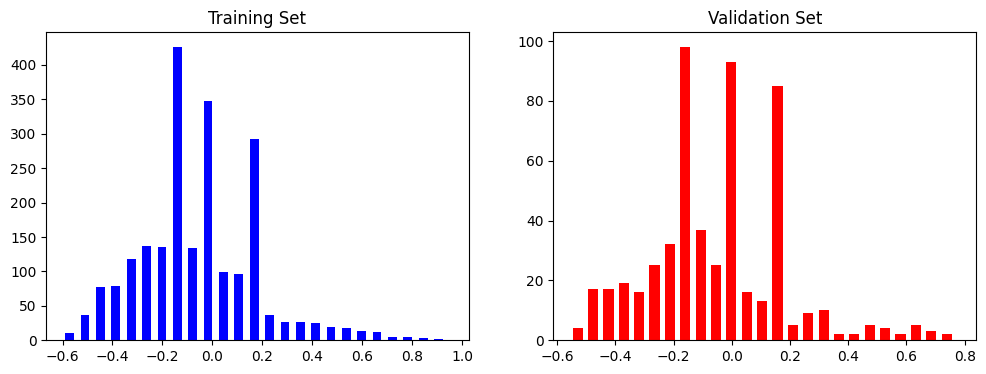

In [8]:
fix, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(steer_train, bins=num_bins, width=0.035, color='blue')
axes[0].set_title('Training Set')
axes[1].hist(steer_valid, bins=num_bins, width=0.035, color='red')
axes[1].set_title('Validation Set')

In [9]:
def zoom(img):
    zoom = A.Compose(
        [A.Affine(scale=(1.0, 1.3))]
    )
    augmented = zoom(image=img)
    return augmented["image"]

Text(0.5, 1.0, 'Zoomed Image')

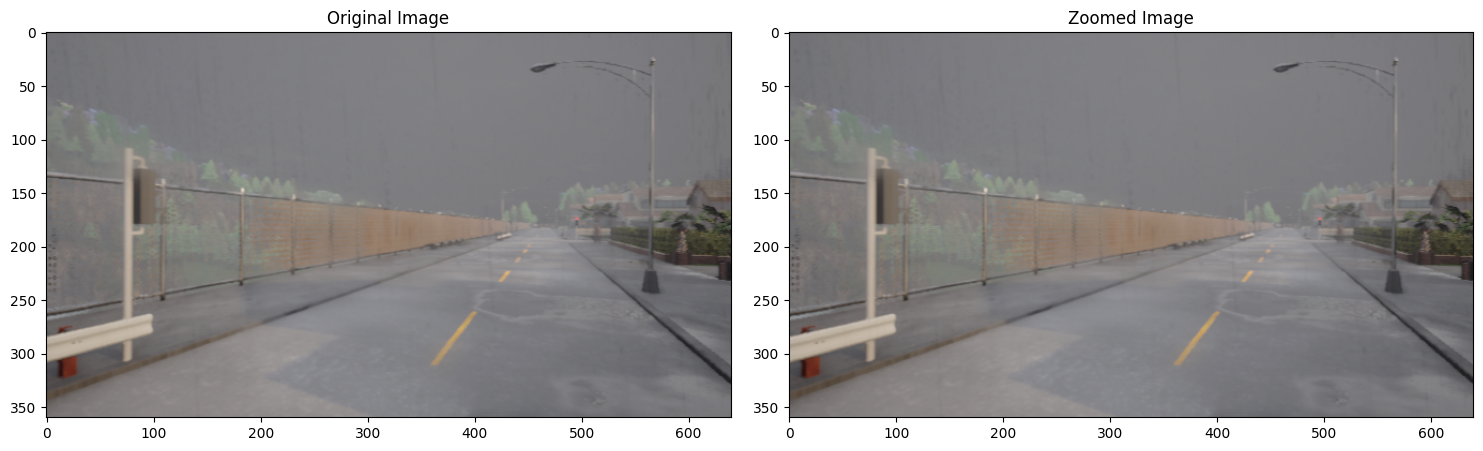

In [10]:
random_index = random.randint(0, 1000)
image = rgb_paths[random_index]

original_image = mpimg.imread(image)

zoomed_image = zoom(original_image)

fig, axes = plt.subplots(1, 2, figsize=(15, 10))
fig.tight_layout()
axes[0].imshow(original_image)
axes[0].set_title('Original Image')
axes[1].imshow(zoomed_image)
axes[1].set_title('Zoomed Image')

In [10]:
def pan(img):
    pan = A.Compose(
        [A.Affine(translate_percent={"x" : (-0.1, 0.1), "y" : (-0.1, 0.1)})]
    )
    augmented = pan(image=img)
    return augmented["image"]

Text(0.5, 1.0, 'Panned Image')

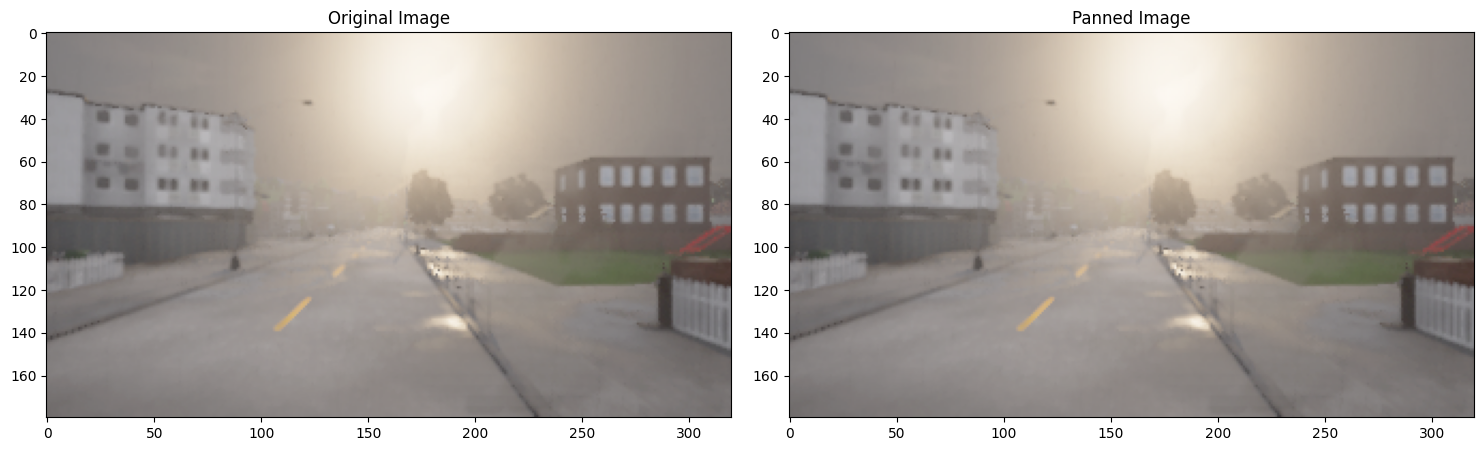

In [11]:
random_index = random.randint(0, 1000)
image = rgb_paths[random_index]

original_image = mpimg.imread(image)

panned_image = pan(original_image)

fig, axes = plt.subplots(1, 2, figsize=(15, 10))
fig.tight_layout()
axes[0].imshow(original_image)
axes[0].set_title('Original Image')
axes[1].imshow(panned_image)
axes[1].set_title('Panned Image')

In [12]:
def img_random_brightness(img):
    brightness = A.RandomBrightnessContrast(
    brightness_limit=0.2,
    contrast_limit=0.0,
    p=1.0)

    augmented = brightness(image=img)
    return augmented["image"]

Text(0.5, 1.0, 'Brightness Altered Image')

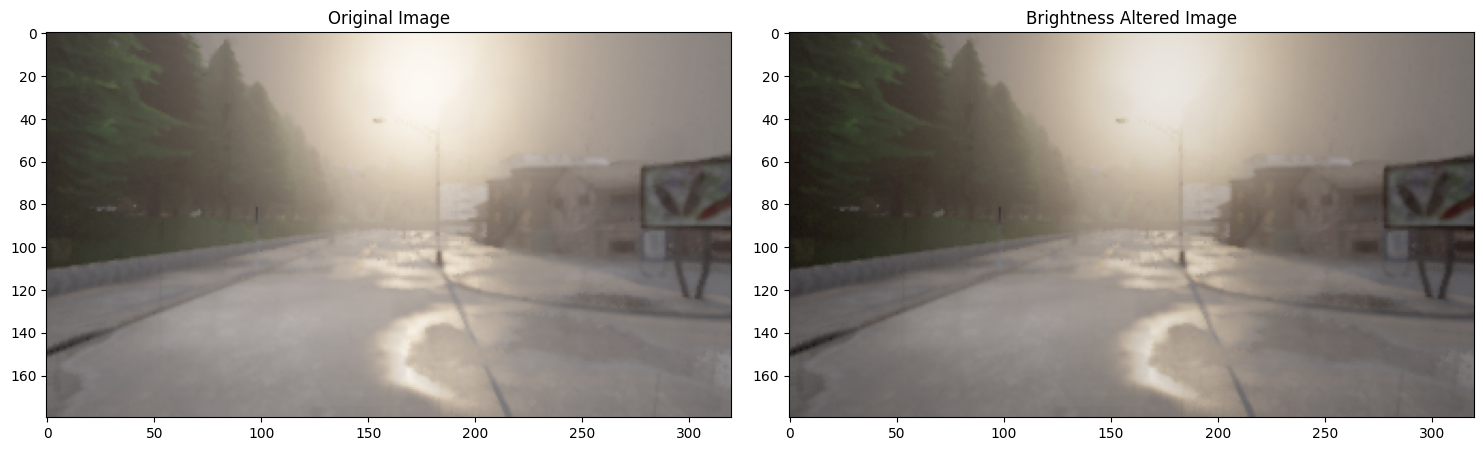

In [13]:
random_index = random.randint(0, 1000)
image = rgb_paths[random_index]

original_image = mpimg.imread(image)
brightness_altered_img = img_random_brightness(original_image)

fig, axes = plt.subplots(1, 2, figsize=(15, 10))
fig.tight_layout()
axes[0].imshow(original_image)
axes[0].set_title('Original Image')
axes[1].imshow(brightness_altered_img)
axes[1].set_title('Brightness Altered Image')

In [14]:
def img_random_flip(img, steering_angle):
    img = cv2.flip(img, 1)
    steering_angle = -steering_angle
    return img, steering_angle

Text(0.5, 1.0, 'Flipped Image - Steering Angle: -0.7039769530296326')

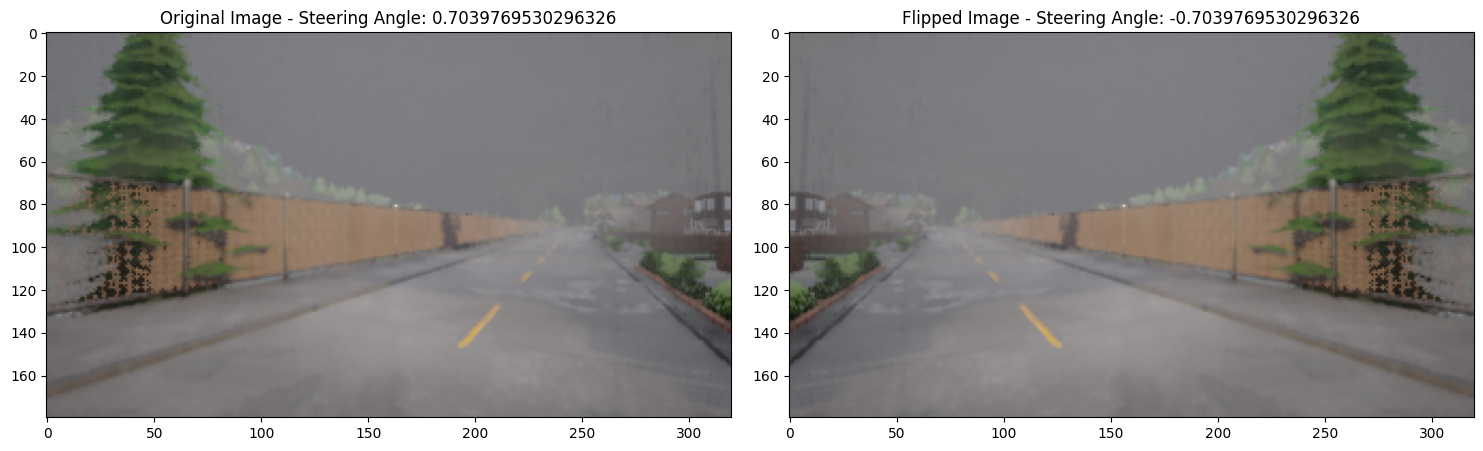

In [17]:
random_index = random.randint(0, 1000)
image = rgb_paths[random_index]
steering_angle = steerings[random_index]

original_image = mpimg.imread(image)

flipped_image, flipped_steering = img_random_flip(original_image, steering_angle)

fig, axes = plt.subplots(1, 2, figsize=(15, 10))
fig.tight_layout()
axes[0].imshow(original_image)
axes[0].set_title('Original Image - Steering Angle: ' + str(steering_angle))
axes[1].imshow(flipped_image)
axes[1].set_title('Flipped Image - Steering Angle: ' + str(flipped_steering))

In [16]:
def random_augment(image, steering_angle):
    image = mpimg.imread(image)

    if np.random.rand() < 0.5:
        image = pan(image)

    if np.random.rand() < 0.5:
        image = zoom(image)
    
    if np.random.rand() < 0.5:
        image = img_random_brightness(image)
    
    if np.random.rand() < 0.5:
        image, steering_angle = img_random_flip(image, steering_angle)
    
    return image, steering_angle

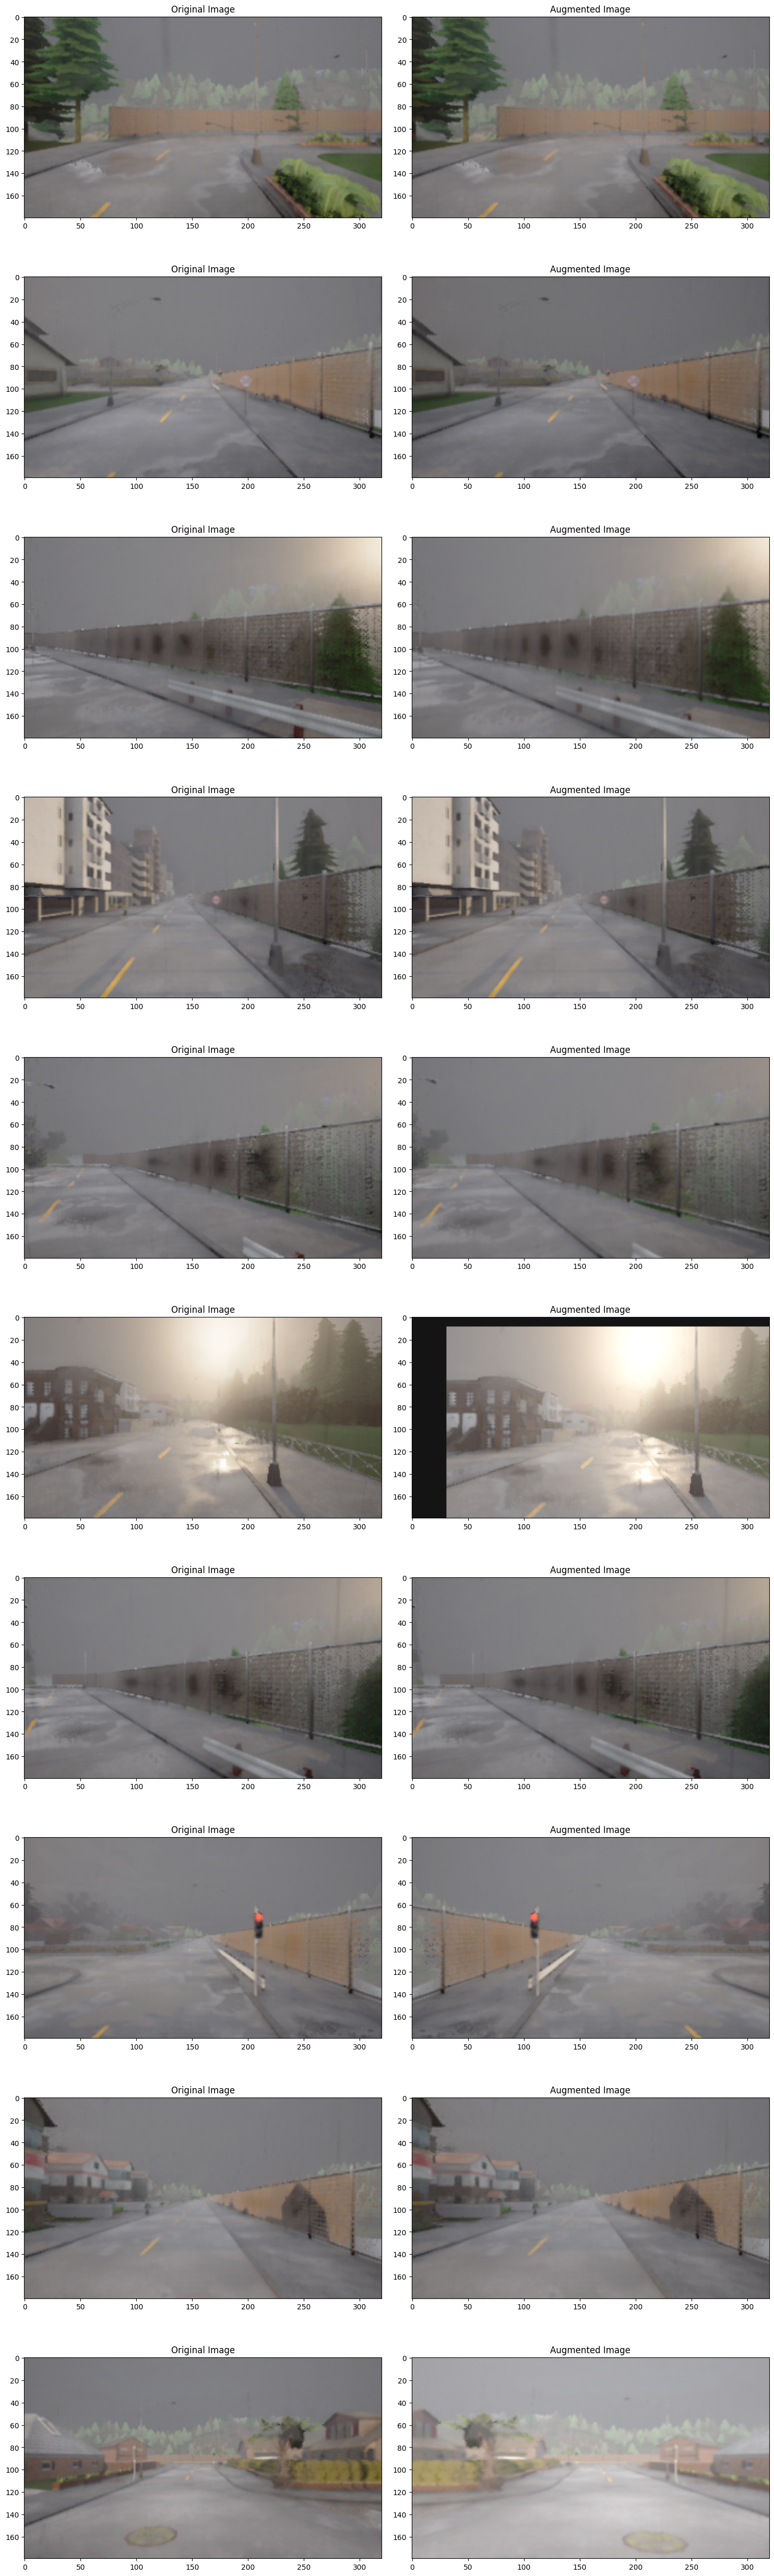

In [18]:
ncol = 2
nrow = 10

fig, axes = plt.subplots(nrow, ncol, figsize=(15, 50))
fig.tight_layout()

for i in range(10):
    randnum = random.randint(0, len(rgb_paths) - 1)
    random_image = rgb_paths[randnum]
    random_steering = steerings[randnum]

    original_image = mpimg.imread(random_image)

    augmented_image, augmented_steering = random_augment(random_image, random_steering)

    axes[i][0].imshow(original_image)
    axes[i][0].set_title('Original Image')
    axes[i][1].imshow(augmented_image)
    axes[i][1].set_title('Augmented Image')

In [58]:
def img_preprocess(img):
    img = img[90:, :, :]
    img = cv2.cvtColor(img, cv2.COLOR_RGB2YUV)
    img = cv2.GaussianBlur(img, (3, 3), 0)
    img = cv2.resize(img, (200, 66))

    return img

Text(0.5, 1.0, 'Preprocessed Image')

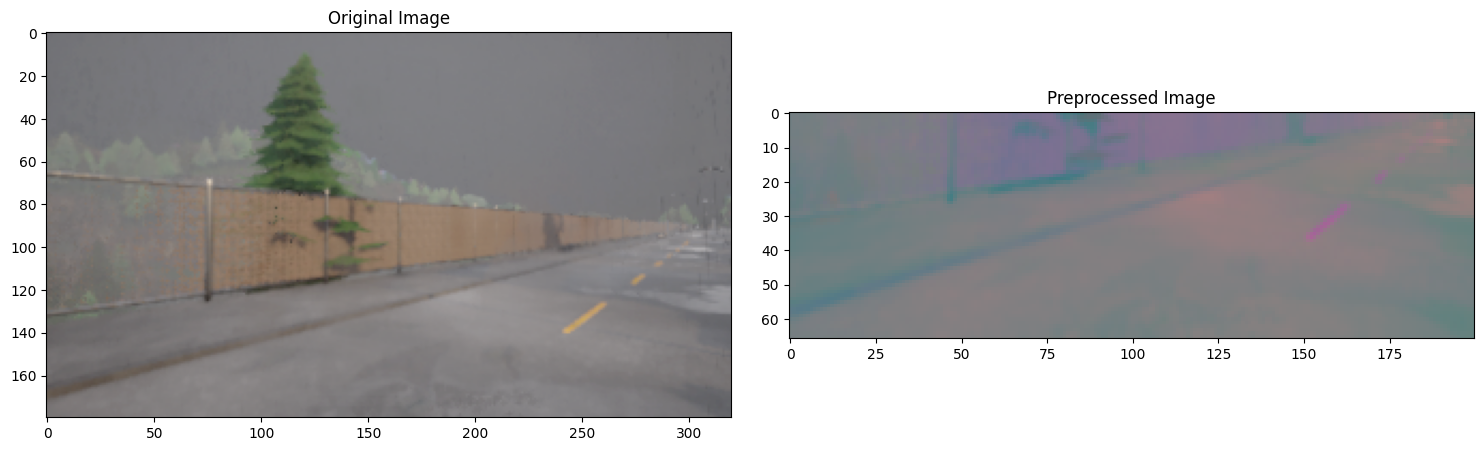

In [59]:
image = rgb_paths[100]
original_image = mpimg.imread(image)
preprocessed_image = img_preprocess(original_image)

fig, axes = plt.subplots(1, 2, figsize=(15, 10))
fig.tight_layout()
axes[0].imshow(original_image)
axes[0].set_title('Original Image')
axes[1].imshow(preprocessed_image)
axes[1].set_title('Preprocessed Image')

In [60]:
def batch_generator(image_paths, steering_angles, batch_size, istraining):
    while True:
        batch_img = []
        batch_steering = []

        for i in range(batch_size):
            random_index = random.randint(2, len(image_paths) - 1)

            if istraining:
                img, steering = random_augment(image_paths[random_index], steering_angles[random_index])
            else:
                img = mpimg.imread(image_paths[random_index])
                steering = steering_angles[random_index]
            
            img = img_preprocess(img)
            batch_img.append(img)
            batch_steering.append(steering)
        
        batch_img = np.array(batch_img, dtype=np.float32)
        batch_steering = np.array(batch_steering, dtype=np.float32)

        yield (np.asarray(batch_img), np.asarray(batch_steering))

Text(0.5, 1.0, 'Validation Image')

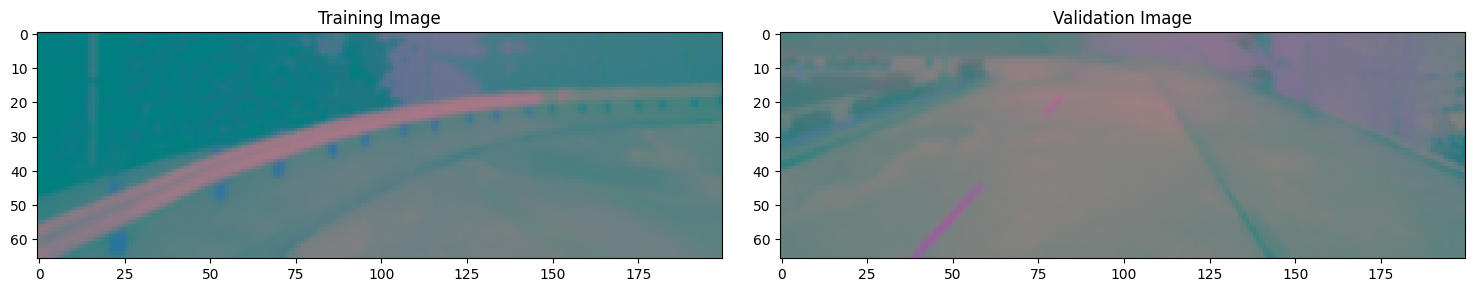

In [61]:
train_gen, steer_train_gen = next(batch_generator(rgb_train, steer_train, 1, 1))
valid_gen, steer_valid_gen = next(batch_generator(rgb_valid, steer_valid, 1, 0))

rgb_train_gen = train_gen[0]
rgb_valid_gen = valid_gen[0]

fig, axes = plt.subplots(1, 2, figsize=(15, 10))
fig.tight_layout()

axes[0].imshow(rgb_train_gen)
axes[0].set_title('Training Image')
axes[1].imshow(rgb_valid_gen)
axes[1].set_title('Validation Image')

In [66]:
def steering_model():
  model = Sequential()
  model.add(Convolution2D(24, (5, 5), strides=(2, 2), input_shape=(66, 200, 3), activation='elu'))
  model.add(Convolution2D(36, (5, 5), strides=(2, 2), activation='elu'))
  model.add(Convolution2D(48, (5, 5), strides=(2, 2), activation='elu'))
  model.add(Convolution2D(64, (3, 3), activation='elu'))
  model.add(Convolution2D(64, (3, 3), activation='elu'))

  model.add(Flatten())
  model.add(Dense(100, activation='elu'))
  model.add(Dense(50, activation='elu'))
  model.add(Dense(10, activation='elu'))
  model.add(Dense(1))

  optimizer = Adam(learning_rate=1e-3)
  model.compile(loss='mse', optimizer=optimizer)

  return model


In [67]:
model = steering_model()
print(model.summary())

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 31, 98, 24)     │         1,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 14, 47, 36)     │        21,636 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 5, 22, 48)      │        43,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 3, 20, 64)      │        27,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 1, 18, 64)      │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │       115,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           510 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 252,219 (985.23 KB)

 Trainable params: 252,219 (985.23 KB)

 Non-trainable params: 0 (0.00 B)

None


In [ ]:
history = model.fit(batch_generator(rgb_train, steer_train, batch_size=100, istraining=1), steps_per_epoch=300, epochs=10, validation_data=(batch_generator(rgb_valid, steer_valid, batch_size=100, istraining=0)), validation_steps=200, verbose=1, shuffle=1)

Epoch 1/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 163s 543ms/step - loss: 0.0866 - val_loss: 0.0340
Epoch 2/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 150s 499ms/step - loss: 0.0356 - val_loss: 0.0300
Epoch 3/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 165s 549ms/step - loss: 0.0327 - val_loss: 0.0276
Epoch 4/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 164s 546ms/step - loss: 0.0287 - val_loss: 0.0214
Epoch 5/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 165s 548ms/step - loss: 0.0264 - val_loss: 0.0188
Epoch 6/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 138s 459ms/step - loss: 0.0233 - val_loss: 0.0169
Epoch 7/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 149s 496ms/step - loss: 0.0210 - val_loss: 0.0175
Epoch 8/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 740s 2s/step - loss: 0.0202 - val_loss: 0.0166
Epoch 9/10
300/300 ━━━━━━━━━━━━━━━━━━━━ 0s 412ms/step - loss: 0.0196

Text(0.5, 0, 'Epoch')

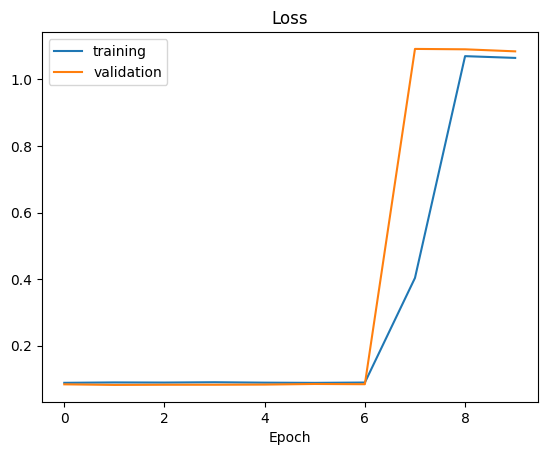

In [26]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['training', 'validation'])
plt.title('Loss')
plt.xlabel('Epoch')

In [27]:
model.save('steering_model.h5')